<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana6/Semana_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Semana 6

In [34]:
# ==============================================================================
# LABORATÓRIO SEMANA 06 - ENGENHARIA DE DADOS E VISUALIZAÇÃO PROFISSIONAL
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Configuração global de estética para deixar com cara de Dashboard Profissional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5) # Tamanho padrão das figuras

## Aula 1

In [36]:
print("==============================================================================")
print("AULA 1: TRANSFORMAÇÕES, CONCATENAÇÃO E CRUZAMENTOS")
print("==============================================================================")

# 1. CRIANDO DADOS SIMULADOS
# Simulando a extração de sistemas legados que enviam arquivos separados por mês

dados_jan = pd.DataFrame({'ID_Venda': [1, 2], 'ID_Cli': [101, 102], 'Valor': [150.0, 300.0]})

dados_fev = pd.DataFrame({'ID_Venda': [3, 4], 'ID_Cli': [101, 103], 'Valor': [200.0, 450.0]})

# Tabela do sistema de cadastro de clientes
cadastro = pd.DataFrame({
    'ID_Cli': [101, 102, 103, 104],
    'Nome': ['Ana', 'Bruno', 'Carlos', 'Diana'],
    'Idade': [25, 45, 30, 22]
})

AULA 1: TRANSFORMAÇÕES, CONCATENAÇÃO E CRUZAMENTOS


In [37]:
# ------------------------------------------------------------------
# TÓPICO 1: pd.concat (Empilhamento)
# ------------------------------------------------------------------
# Juntamos Janeiro e Fevereiro. ignore_index=True refaz o índice de 0 a 3.
df_vendas_ano = pd.concat([dados_jan, dados_fev], ignore_index=True)

print("\n[RESULTADO CONCAT] - Vendas de Jan e Fev Empilhadas:")
display(df_vendas_ano)


[RESULTADO CONCAT] - Vendas de Jan e Fev Empilhadas:


,ID_Venda,ID_Cli,Valor
0,1,101,150.0
1,2,102,300.0
2,3,101,200.0
3,4,103,450.0


In [38]:
# ------------------------------------------------------------------
# TÓPICO 2: pd.merge (O Relacionamento de Tabelas)
# ------------------------------------------------------------------
# Cruzamos as vendas anuais com o cadastro usando o 'ID_Cli' (O nosso PROCV)
# Usamos 'left' para garantir que não perderemos nenhuma venda se o cliente não estiver cadastrado.
df_master = pd.merge(df_vendas_ano, cadastro, on='ID_Cli', how='left')
print("\n[RESULTADO MERGE] - Tabela Master (Vendas enriquecidas com Cadastro):")
display(df_master)


[RESULTADO MERGE] - Tabela Master (Vendas enriquecidas com Cadastro):


,ID_Venda,ID_Cli,Valor,Nome,Idade
0,1,101,150.0,Ana,25
1,2,102,300.0,Bruno,45
2,3,101,200.0,Ana,25
3,4,103,450.0,Carlos,30


In [39]:
# ------------------------------------------------------------------
# TÓPICO 3: Transformação Condicional Vetorizada (np.where)
# ------------------------------------------------------------------
# Regra do Negócio: Se a venda for acima de 250, é 'Alto Valor', senão é 'Baixo Valor'.
df_master['Categoria_Venda'] = np.where(df_master['Valor'] > 250, 'Alto Valor', 'Baixo Valor')

In [40]:
# ------------------------------------------------------------------
# TÓPICO 4: Múltiplas Condições Vetorizadas (np.select)
# ------------------------------------------------------------------
print("\n--- Aplicando np.select para Múltiplas Categorias ---")

# Cenário: O 'np.where' é ótimo para 2 opções (Verdadeiro ou Falso).
# Mas e se precisarmos de 3 ou mais categorias? O np.select resolve isso de forma limpa!
# Vamos classificar o cliente com base na idade:
# 1. Menor de 25 anos -> 'Jovem'
# 2. Entre 25 e 40 anos -> 'Adulto'
# 3. Acima de 40 anos -> 'Sénior'

# PASSO 1: Criamos uma lista com as condições (Regras Matemáticas)
condicoes = [
    (df_master['Idade'] < 25),
    (df_master['Idade'] >= 25) & (df_master['Idade'] <= 40),
    (df_master['Idade'] > 40)
]

# PASSO 2: Criamos uma lista com os resultados para cada condição (na mesma ordem!)
resultados = ['Jovem', 'Adulto', 'Sénior']

# PASSO 3: Aplicamos o np.select passando as condições, resultados e um valor padrão (default) caso algo falhe.
df_master['Faixa_Etaria'] = np.select(condicoes, resultados, default='Desconhecido')

print("\n[RESULTADO NP.SELECT] - Tabela Master com Faixa Etária:")
display(df_master[['Nome', 'Idade', 'Faixa_Etaria']])


--- Aplicando np.select para Múltiplas Categorias ---

[RESULTADO NP.SELECT] - Tabela Master com Faixa Etária:


,Nome,Idade,Faixa_Etaria
0,Ana,25,Adulto
1,Bruno,45,Sénior
2,Ana,25,Adulto
3,Carlos,30,Adulto


In [41]:
# ------------------------------------------------------------------
# TÓPICO 5: O Poder do .apply() com Lambda
# ------------------------------------------------------------------
# Vamos criar uma coluna de Score de Risco.
# Regra complexa simulada: Pega a idade, multiplica pelo valor da compra e divide por 100.
df_master['Score_Risco'] = df_master.apply(lambda linha: (linha['Idade'] * linha['Valor']) / 100, axis=1)

In [42]:
print("\n[RESULTADO FINAL] - Tabela Master Pós-Transformações da Engenharia de Dados:")
display(df_master)


[RESULTADO FINAL] - Tabela Master Pós-Transformações da Engenharia de Dados:


,ID_Venda,ID_Cli,Valor,Nome,Idade,Categoria_Venda,Faixa_Etaria,Score_Risco
0,1,101,150.0,Ana,25,Baixo Valor,Adulto,37.5
1,2,102,300.0,Bruno,45,Alto Valor,Sénior,135.0
2,3,101,200.0,Ana,25,Baixo Valor,Adulto,50.0
3,4,103,450.0,Carlos,30,Alto Valor,Adulto,135.0


## Aula 2

In [43]:
print("\n\n==============================================================================")
print("AULA 2: MATPLOTLIB E SEABORN")
print("==============================================================================")

# Gerando um Dataset maior e aleatório para gráficos mais realistas
np.random.seed(42)
dias = pd.date_range(start='2024-01-01', periods=100)
df_graficos = pd.DataFrame({
    'Data': dias,
    'Acessos_Site': np.random.normal(5000, 1000, 100).astype(int),
    'Vendas': np.random.normal(100, 20, 100).astype(int),
    'Campanha': np.random.choice(['Facebook', 'Google', 'Email'], 100)
})
# Forçando uma correlação para o Scatter Plot (Quanto mais acessos, mais vendas)
df_graficos['Vendas'] = df_graficos['Vendas'] + (df_graficos['Acessos_Site'] * 0.05)
display(df_graficos)




AULA 2: MATPLOTLIB E SEABORN


,Data,Acessos_Site,Vendas,Campanha
0,2024-01-01,5496,345.80,Google
1,2024-01-02,4861,334.05,Google
2,2024-01-03,5647,375.35,Facebook
3,2024-01-04,6523,409.15,Facebook
4,2024-01-05,4765,334.25,Facebook
...,...,...,...,...
95,2024-04-05,3536,283.80,Email
96,2024-04-06,5296,346.80,Email
97,2024-04-07,5261,366.05,Google
98,2024-04-08,5005,351.25,Email


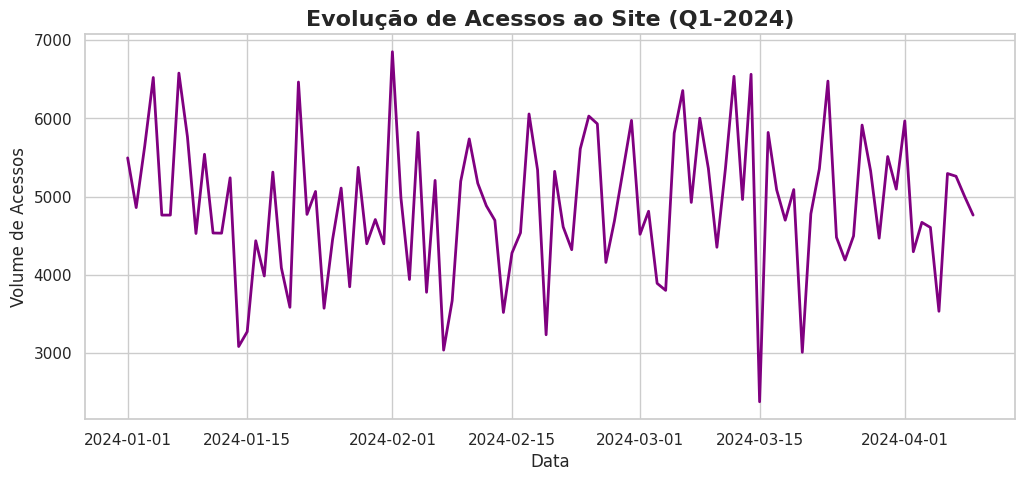

In [44]:
# ------------------------------------------------------------------
# 1. GRÁFICO DE LINHA (Análise de Séries Temporais)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 5)) # Passo 1: Criar o tamanho da Figura (Matplotlib)
# Passo 2: O Seaborn pinta o gráfico
sns.lineplot(data=df_graficos, x='Data', y='Acessos_Site', color='purple', linewidth=2)
# Passo 3: O Matplotlib customiza o acabamento
plt.title('Evolução de Acessos ao Site (Q1-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Volume de Acessos')
plt.show() # Exibe


/tmp/ipykernel_1554/2383101406.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendas_por_campanha, x='Campanha', y='Vendas', palette='viridis')


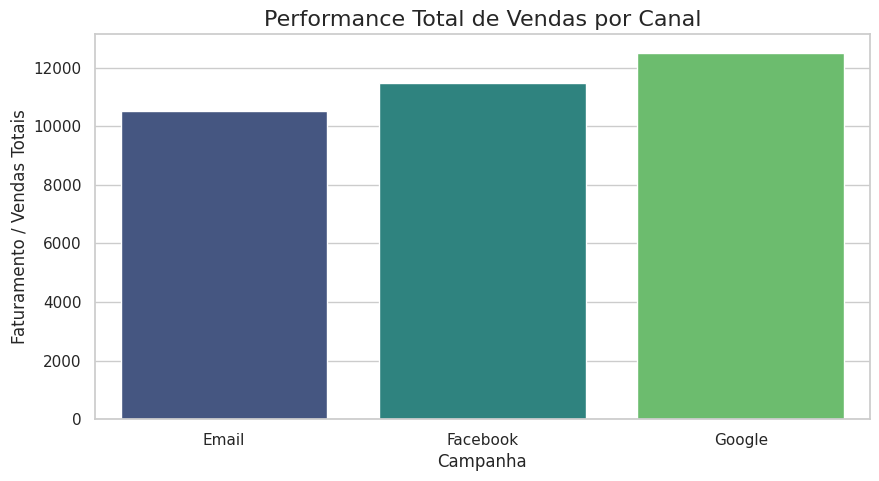

In [45]:
# ------------------------------------------------------------------
# 2. GRÁFICO DE BARRAS (Análise de Categorias)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# Somando as vendas por campanha
vendas_por_campanha = df_graficos.groupby('Campanha')['Vendas'].sum().reset_index()

sns.barplot(data=vendas_por_campanha, x='Campanha', y='Vendas', palette='viridis')
plt.title('Performance Total de Vendas por Canal', fontsize=16)
plt.ylabel('Faturamento / Vendas Totais')
plt.show()

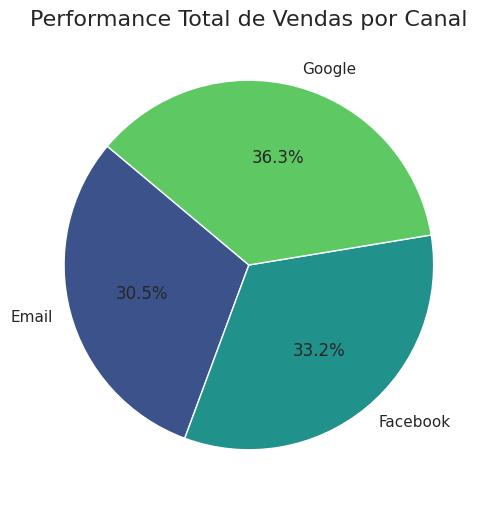

In [46]:
categorias = vendas_por_campanha['Campanha']
valores = vendas_por_campanha['Vendas']

# Configurando uma paleta de cores do Seaborn para o Matplotlib
cores = sns.color_palette('viridis', n_colors=len(valores))

# Criando a figura e o gráfico (aspect='equal' mantém o formato circular)
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(valores, labels=categorias, colors=cores, autopct='%1.1f%%', startangle=140)

# Título e ajustes
ax.set_title('Performance Total de Vendas por Canal', fontsize=16)
# Em gráficos de pizza, o eixo Y costuma ser redundante, então removemos a label do eixo Y
# e adicionamos um label descritivo geral se necessário.
plt.ylabel('')

plt.show()

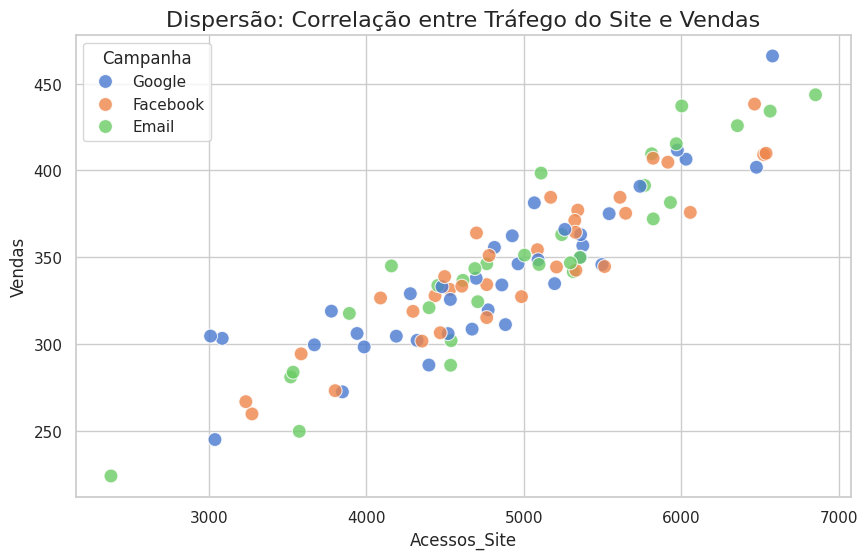

In [47]:
# ------------------------------------------------------------------
# 3. GRÁFICO DE DISPERSÃO (Correlação de Machine Learning)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
# Cada ponto é um dia. O eixo X é o acesso, o Y é a venda. A cor difere a campanha!
sns.scatterplot(data=df_graficos, x='Acessos_Site', y='Vendas', hue='Campanha', s=100, alpha=0.8)
plt.title('Dispersão: Correlação entre Tráfego do Site e Vendas', fontsize=16)
plt.show()

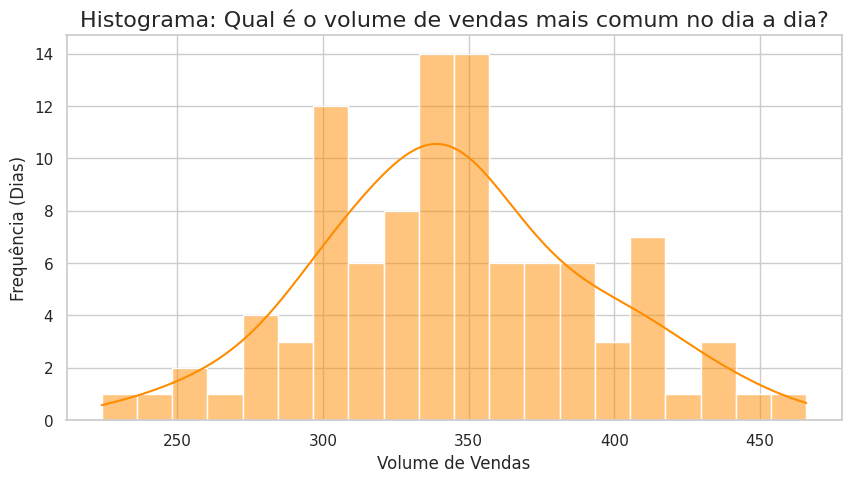

In [48]:
# ------------------------------------------------------------------
# 4. HISTOGRAMA (Análise de Distribuição e Frequência)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# kde=True adiciona a linha de tendência (Curva de Densidade) sobre as barras
sns.histplot(data=df_graficos, x='Vendas', bins=20, kde=True, color='darkorange')
plt.title('Histograma: Qual é o volume de vendas mais comum no dia a dia?', fontsize=16)
plt.xlabel('Volume de Vendas')
plt.ylabel('Frequência (Dias)')
plt.show()


/tmp/ipykernel_1554/3443265412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_graficos, x='Campanha', y='Vendas', palette='pastel')


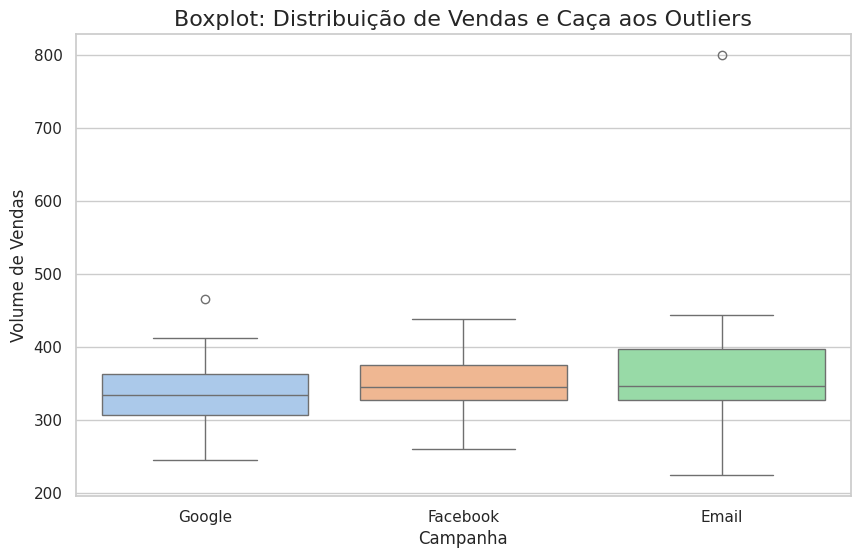

In [49]:
# ------------------------------------------------------------------
# 5. BOXPLOT (Análise Estatística e Identificação de Outliers)
# ------------------------------------------------------------------
# Vamos forçar a criação de um "Outlier" (uma anomalia) no nosso dado para a aula ficar interessante!
df_graficos.loc[10, 'Vendas'] = 800 # Uma venda irreal inserida no dia 10!

plt.figure(figsize=(10, 6))
# Separamos os boxplots por campanha para ver qual canal tem dados mais "estáveis"
sns.boxplot(data=df_graficos, x='Campanha', y='Vendas', palette='pastel')
plt.title('Boxplot: Distribuição de Vendas e Caça aos Outliers', fontsize=16)
plt.ylabel('Volume de Vendas')

plt.show()


/tmp/ipykernel_1554/2556407091.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numerico['Desconto_Aplicado'] = df_numerico['Vendas'] * -0.5 + np.random.normal(0, 5, 100)


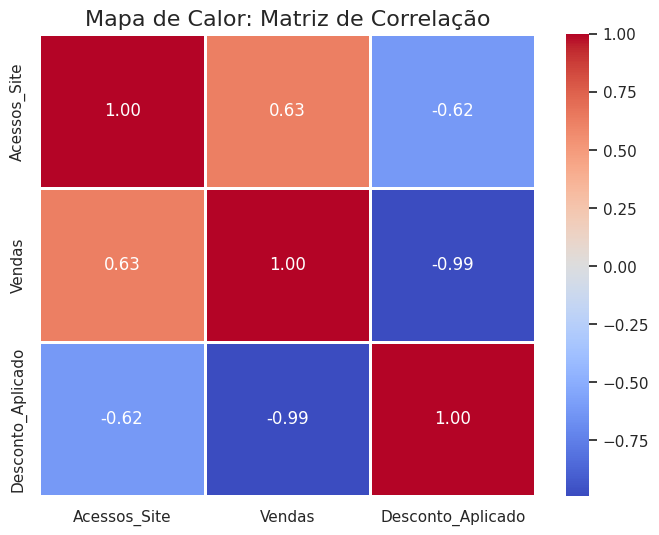

In [50]:
# ------------------------------------------------------------------
# 6. MAPA DE CALOR (Heatmap e Matriz de Correlação)
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))

# Passo 1: O Pandas calcula a matemática (Correlação de Pearson) APENAS nas colunas numéricas
# Criamos um sub-dataframe só com números para não dar erro
df_numerico = df_graficos[['Acessos_Site', 'Vendas']]

# Adicionando uma coluna simulada de 'Desconto' que faz as vendas caírem (Correlação Negativa)
df_numerico['Desconto_Aplicado'] = df_numerico['Vendas'] * -0.5 + np.random.normal(0, 5, 100)

matriz_correlacao = df_numerico.corr()

# Passo 2: O Seaborn pinta os números
# annot=True escreve os números dentro dos quadrados. cmap é a paleta de cores.
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Mapa de Calor: Matriz de Correlação', fontsize=16)
plt.show()

## Aula 3



AULA 3: LAYOUTS, SUBPLOTS E DASHBOARDS CORPORATIVOS


/tmp/ipykernel_1554/1144957213.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 1], data=df_graficos, x='Campanha', y='Vendas', palette='Set2')


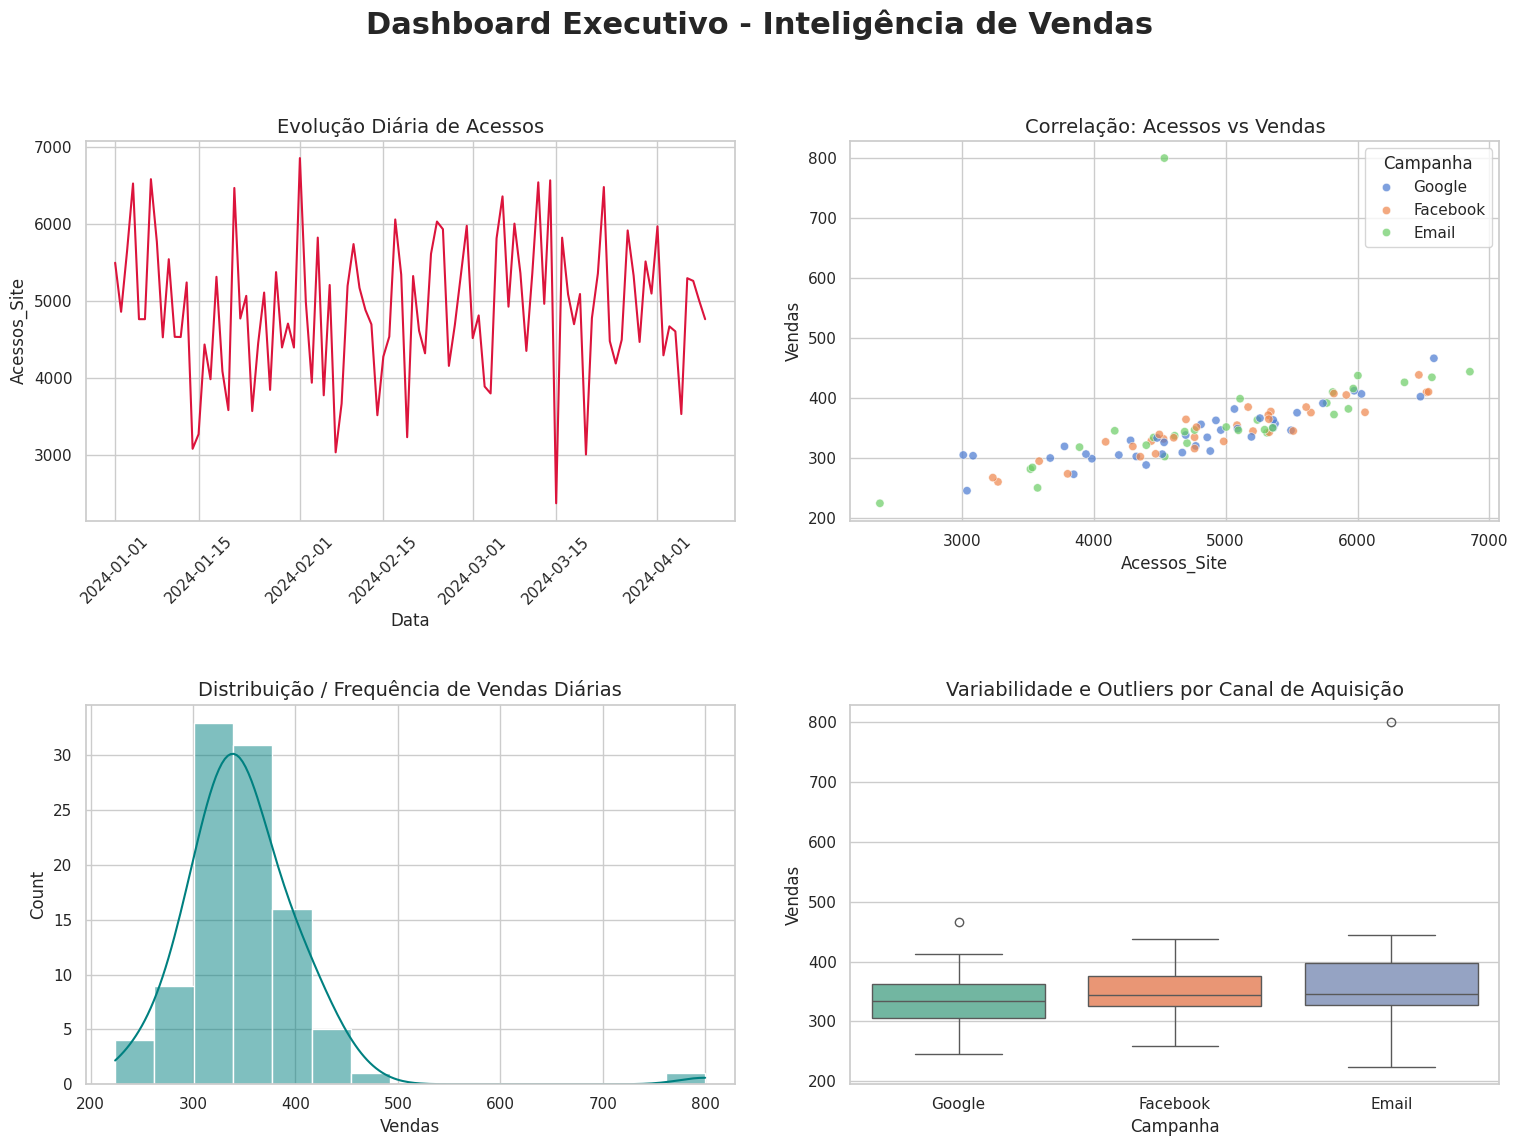

In [51]:
print("\n\n==============================================================================")
print("AULA 3: LAYOUTS, SUBPLOTS E DASHBOARDS CORPORATIVOS")
print("==============================================================================")

# acontece aqui: plt.subplots(linhas, colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# Isso gera uma janela gigante com 4 eixos (0,0), (0,1), (1,0) e (1,1)

# Título Mestre do Dashboard
fig.suptitle('Dashboard Executivo - Inteligência de Vendas', fontsize=22, fontweight='bold', y=0.98)

# -- QUADRO 1: Linha do Tempo (Canto Superior Esquerdo)
sns.lineplot(ax=axes[0, 0], data=df_graficos, x='Data', y='Acessos_Site', color='crimson')
axes[0, 0].set_title('Evolução Diária de Acessos', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45) # Rotacionando as datas para não amassar

# -- QUADRO 2: Gráfico de Dispersão (Canto Superior Direito)
sns.scatterplot(ax=axes[0, 1], data=df_graficos, x='Acessos_Site', y='Vendas', hue='Campanha', alpha=0.7)
axes[0, 1].set_title('Correlação: Acessos vs Vendas', fontsize=14)

# -- QUADRO 3: Gráfico de Barras com Histograma (Canto Inferior Esquerdo)
# Vamos plotar a distribuição de vendas (Quantos dias tivemos 100 vendas, quantos dias 200, etc)
sns.histplot(ax=axes[1, 0], data=df_graficos, x='Vendas', bins=15, kde=True, color='teal')
axes[1, 0].set_title('Distribuição / Frequência de Vendas Diárias', fontsize=14)

# -- QUADRO 4: Gráfico de Boxplot (Canto Inferior Direito) - Preparando para a Aula de EDA da Semana 7!
sns.boxplot(ax=axes[1, 1], data=df_graficos, x='Campanha', y='Vendas', palette='Set2')
axes[1, 1].set_title('Variabilidade e Outliers por Canal de Aquisição', fontsize=14)

# Ajuste Mágico: tight_layout impede que os gráficos fiquem uns por cima dos outros
plt.tight_layout(pad=3.0)
plt.show()